<a href="https://colab.research.google.com/github/Marymelkady/Miscellaneous-/blob/main/animal_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas scikit-learn

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the data
data = pd.read_csv('/content/animal_observations.csv.csv')

# Mapping animal characteristics to labels
animal_labels = {
    "Arabian Oryx": (90, 120, 36, 39, 1, 5),
    "Sand Viper": (50, 120, 20, 30, 0.5, 2),
    "Desert Hedgehog": (20, 30, 35, 38, 0.5, 1),
    "Arabian Cobra": (80, 200, 20, 30, 0.5, 3),
    "Red Fox": (45, 90, 37, 39, 1, 4),
    "Common Scorpion": (5, 10, 20, 30, 0.1, 0.5),
    "Greater Sand Plover": (20, 25, 37, 39, 1, 3),
}

# Prepare the dataset
features = []
labels = []

for animal, (size_min, size_max, temp_min, temp_max, speed_min, speed_max) in animal_labels.items():
    # Create synthetic data for each animal
    for _ in range(100):  # Generate 100 samples for each animal
        size = (size_min + size_max) / 2  # Using midpoints for simplicity
        temperature = (temp_min + temp_max) / 2
        speed = (speed_min + speed_max) / 2
        features.append([size, temperature, speed])
        labels.append(animal)

# Convert to DataFrame
features_df = pd.DataFrame(features, columns=["Size (cm)", "Body Temperature (°C)", "Speed (m/s)"])
labels_df = pd.Series(labels)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_df, labels_df, test_size=0.2, random_state=42)

# Create and train the model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Example usage: Predict for a new observation
new_observation = [[100, 28, 1.5]]  # Example input
predicted_animal = model.predict(new_observation)
print(f"Predicted Animal: {predicted_animal[0]}")

Model Accuracy: 100.00%
Predicted Animal: Sand Viper


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
pip install matplotlib seaborn scikit-learn

Model Accuracy: 100.00%


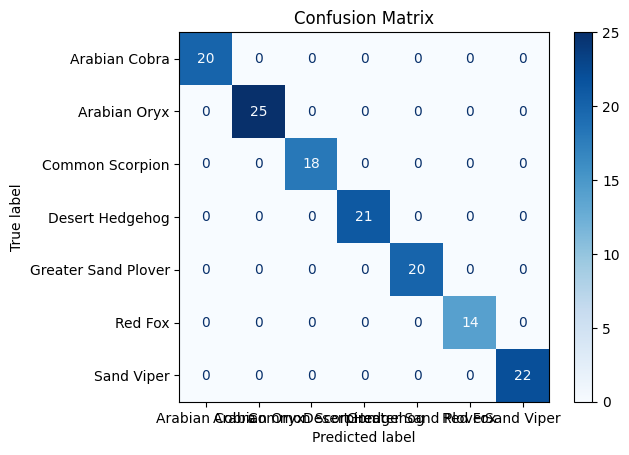

/tmp/ipython-input-2111924951.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Test"], y=[accuracy], palette="viridis")


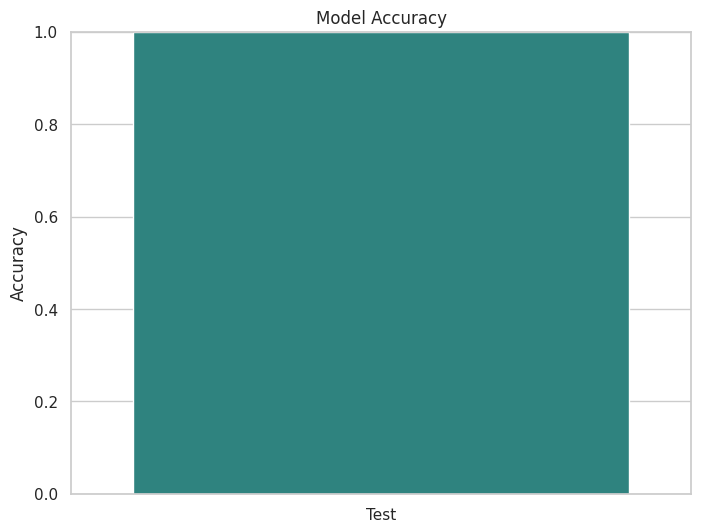

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (assuming you already have the trained model and test data)
data = pd.read_csv('animal_observations.csv.csv')

# Assuming features_df, labels_df, and model are already defined
# Split the dataset into training and testing sets (for demonstration)
X_train, X_test, y_train, y_test = train_test_split(features_df, labels_df, test_size=0.2, random_state=42)

# Predict using the trained model
predictions = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Visualizing Accuracy
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.barplot(x=["Test"], y=[accuracy], palette="viridis")
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [ ]:
pip install scikit-learn

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Create a synthetic dataset for known animals
animal_data = {
    "Arabian Oryx": [105, 37.5, 3],
    "Sand Viper": [85, 25, 1.5],
    "Desert Hedgehog": [25, 36.5, 0.8],
    "Arabian Cobra": [140, 25, 1.5],
    "Red Fox": [67.5, 38, 2.5],
    "Common Scorpion": [7.5, 25, 0.3],
    "Greater Sand Plover": [22.5, 38, 2],
}

# Prepare features and labels
features = np.array(list(animal_data.values()))
labels = np.array(list(animal_data.keys()))

# Fit Nearest Neighbors model
knn = NearestNeighbors(n_neighbors=1)
knn.fit(features)

def predict_species(size, temperature, speed):
    """Predict the species based on size, temperature, and speed."""
    query = np.array([[size, temperature, speed]])
    distance, index = knn.kneighbors(query)

    closest_species = labels[index[0][0]]
    closest_distance = distance[0][0]

    return closest_species, closest_distance

# Example usage
new_observation = [100, 30, 2]  # Example input for unknown species
predicted_species, distance = predict_species(*new_observation)

print(f"Predicted Closest Species: {predicted_species}")
print(f"Distance from known species: {distance:.2f}")

Predicted Closest Species: Arabian Oryx
Distance from known species: 9.07
